# Resonator Spectroscopy

In [1]:
import json
import socket
import numpy as np
import matplotlib.pyplot as plt

from qibosoq.client import execute
from qibosoq.components.base import Qubit, OperationCode, Config, Sweeper, Parameter
from qibosoq.components.pulses import Rectangular

HOST = "192.168.1.68"
PORT = 6000

In [2]:
# Define constants
# DRIVE
Q1_DRIVE_CH = 2
Q2_DRIVE_CH = 5 # without filter

# FLUX
# Q1_FLUX_CH = 3
Q2_FLUX_CH = 3

# READOUT
PROBE_CH = 1
FEEDBACK_CH = 1


In a resonator spectroscopy experiment we send readout pulses with different frequencies.

In [19]:
readout_pulse = Rectangular(
            frequency = 7300, #MHz
            amplitude = 0.3,
            relative_phase = 0,
            start_delay = 0,
            duration = 3,
            name = "readout_pulse",
            type = "readout",
            dac = PROBE_CH,
            adc = FEEDBACK_CH
)
sequence = [readout_pulse]

config = Config(
    relaxation_time = 10, # in us
    ro_time_of_flight = 350,
    reps = 10000
)
qubit = Qubit(
    bias = 0,
    dac = Q2_FLUX_CH
)

readout_frequency = 7330, # 7511.552 # MHZ
experiment_points = 100
frequency_range = np.linspace(-8, 8, experiment_points) + readout_frequency

high power (1) peak 7332.666666666667 MHz
low power (0.3) peak 7330.404040404041 MHz


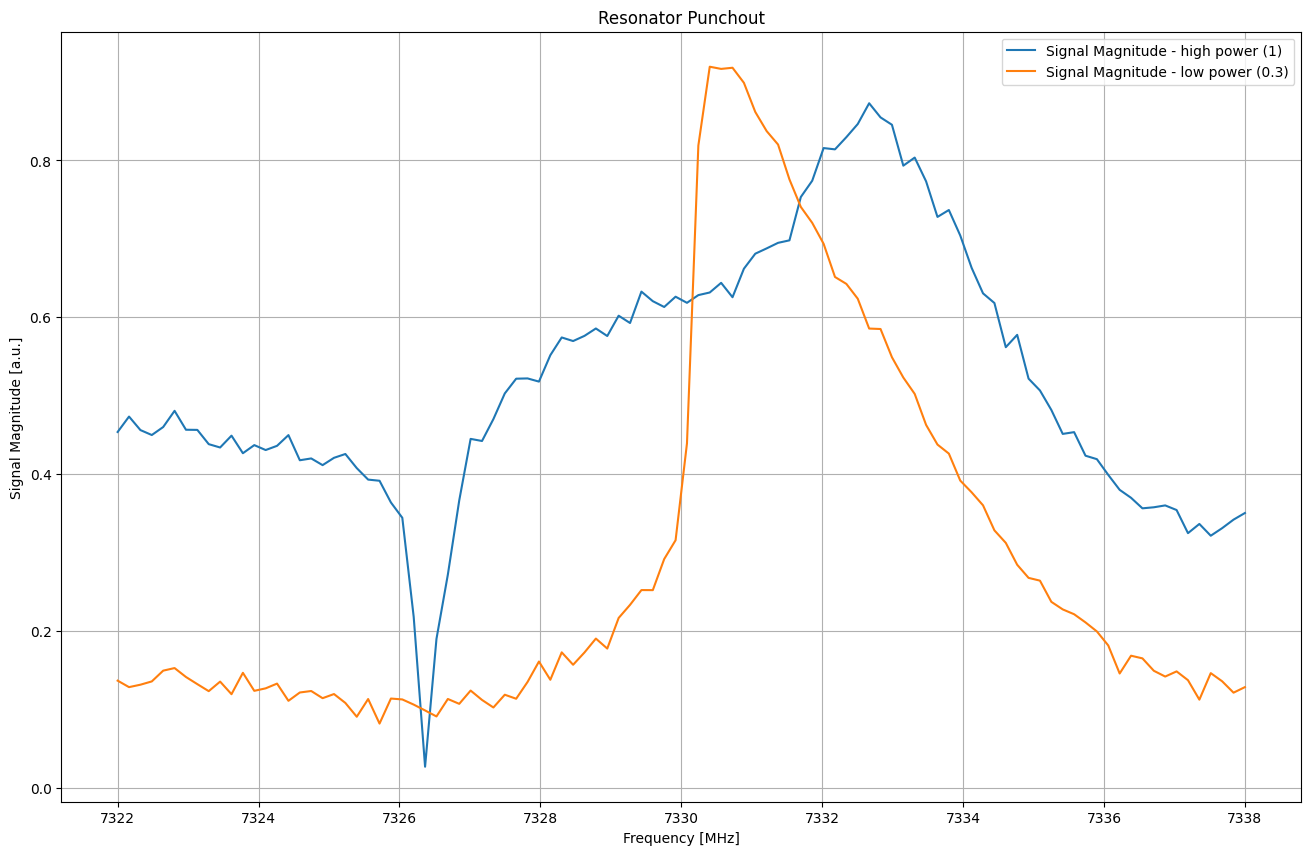

In [20]:
program = None
# Plot results.
plt.figure(1, figsize=(16,10))
hp_gain = 1
lp_gain = 0.3


for gain, title in [(hp_gain, f"high power ({hp_gain})"), (lp_gain, f"low power ({lp_gain})")]:
    readout_pulse.amplitude = gain
    results=[]

    for frequency in frequency_range:
        readout_pulse.frequency = frequency
        sequence = [readout_pulse]
        server_commands = {
            "operation_code": OperationCode.EXECUTE_PULSE_SEQUENCE,
            "cfg": config,
            "sequence": sequence,
            "qubits": [qubit],
        }

        i, q = execute(server_commands, HOST, PORT)
        results.append([i[0][0], q[0][0]])
    results=np.array(results).transpose()
    signal_magnitude = np.abs(results[0] + 1j*results[1])
    plt.plot(frequency_range, signal_magnitude,label=f"Signal Magnitude - {title}")
    print(f"{title} peak {frequency_range[np.argmax(signal_magnitude)]} MHz")
    
plt.ylabel("Signal Magnitude [a.u.]")
plt.xlabel("Frequency [MHz]")
plt.title("Resonator Punchout")
plt.legend()
plt.grid()


Next, we can define the sweeper:

In [35]:
sweeper = Sweeper(
            parameters = [Parameter.FREQUENCY],
            indexes = [0],
            starts = [frequency_range[0]],
            stops = [frequency_range[-1]],
            expts = experiment_points
)
sweeper

Sweeper(expts=100, parameters=[<Parameter.FREQUENCY: 'freq'>], indexes=[0], starts=array([7322.]), stops=array([7338.]))

And we can execute and plot the results:

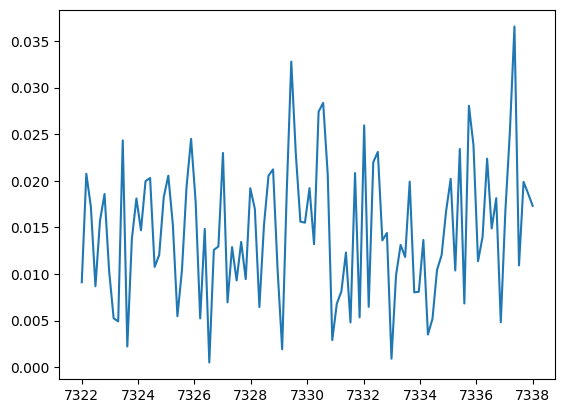

In [34]:
server_commands = {
    "operation_code": OperationCode.EXECUTE_SWEEPS,
    "cfg": config,
    "sequence": sequence,
    "qubits": [qubit],
    "sweepers": [sweeper],
}

i, q = execute(server_commands, HOST, PORT) # frequency sweeps don't work !!!!!!!!!

frequency = np.linspace(sweeper.starts[0], sweeper.stops[0], sweeper.expts)
results = np.array(i[0][0]) + 1j * np.array(q[0][0])
plt.plot(frequency, np.abs(results))

```
INFO :: 2024-05-02 09:56:07 ::  
// Program

                regwi 1, $12, 834666494;        //freq = 834666494
                regwi 1, $13, 0;                //phase = 0
                regwi 1, $15, 9829;             //gain = 9829
                regwi 1, $16, 590976;           //phrst| stdysel | mode | | outsel = 0b01001 | length = 1152 
                synci 819;
                regwi 0, $13, 0;
                regwi 0, $14, 9999;
				
LOOP_rep:       regwi 1, $12, 823481685;        //'gen1_freq' <= 823481685 (7322.0 MHz)
                regwi 0, $17, 99;
				
LOOP_gen1_freq: synci 50;
                regwi 0, $16, 32;               //out = 0b0000000000100000
                seti 7, 0, $16, 350;            //ch =0 out = $16 @t = 0
                seti 7, 0, $0, 360;             //ch =0 out = 0 @t = 0
                regwi 1, $17, 0;                //t = 0
                set 1, 1, $12, $13, $0, $15, $16, $17;//ch = 1, pulse @t = $17
                synci 1228;
                waiti 0, 0;
                synci 50;
                synci 4096;
                mathi 0, $13, $13 + 1;
                memwi 0, $13, 1;
                mathi 1, $12, $12 + 112978;     // 'gen1_freq' <= 'gen1_freq' + 112978 (0.16161616161616163 MHz)
                loopnz 0, $17, @LOOP_gen1_freq;
                loopnz 0, $14, @LOOP_rep;
                end ;

```